In [1]:
import pandas as pd

In [2]:
data= pd.read_csv('results.csv')

In [3]:
data

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
0,0,0.071029,0.024315,0.066896,0.18325,0.44755,0.22958,0.12740,0.021524,0.005872,0.040695,0.070123,0.003320,0.003320
1,1,0.044014,0.013671,0.053937,0.53407,0.54644,0.53711,0.32709,0.017924,0.004254,0.028716,0.039464,0.005994,0.005994
2,2,0.043625,0.013058,0.046599,0.53623,0.52625,0.55521,0.31777,0.022165,0.005921,0.024375,0.008146,0.008009,0.008009
3,3,0.042370,0.012636,0.038556,0.74923,0.81465,0.86083,0.54678,0.019035,0.004069,0.013670,0.007030,0.007030,0.007030
4,4,0.038510,0.012069,0.034214,0.83281,0.88479,0.90665,0.60955,0.018616,0.003763,0.010660,0.007030,0.007030,0.007030
5,5,0.036096,0.011640,0.030552,0.90711,0.92134,0.96722,0.71903,0.014901,0.003114,0.006706,0.006040,0.006040,0.006040
6,6,0.035758,0.011378,0.029724,0.94875,0.94957,0.97855,0.73684,0.013695,0.003023,0.005003,0.005050,0.005050,0.005050
7,7,0.032215,0.010869,0.026136,0.95197,0.96436,0.98383,0.75660,0.013134,0.002928,0.004397,0.004060,0.004060,0.004060
8,8,0.030349,0.010642,0.025837,0.96706,0.98182,0.98910,0.80611,0.011191,0.002662,0.003152,0.003070,0.003070,0.003070
9,9,0.028049,0.010340,0.024489,0.97160,0.97556,0.98766,0.83093,0.010504,0.002540,0.002834,0.002080,0.002080,0.002080


In [4]:
import matplotlib

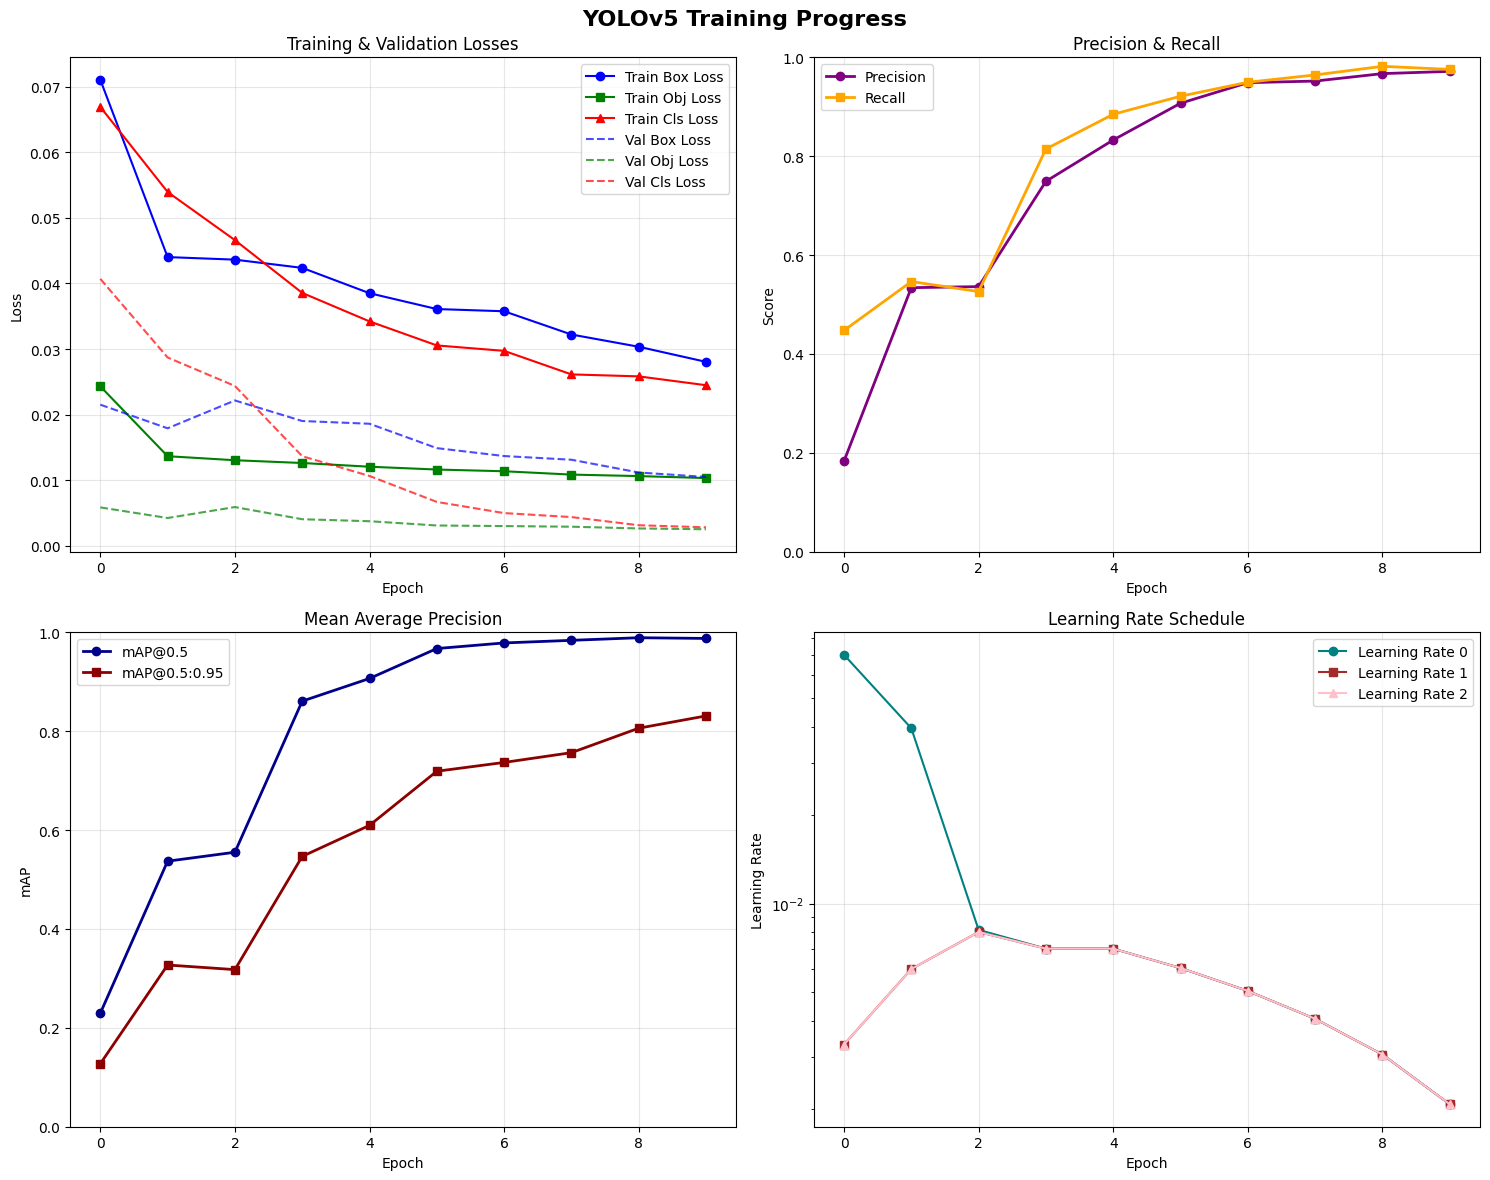

=== Training Progress Analysis ===
총 에포크: 10
최종 mAP@0.5: 0.9877
최종 mAP@0.5:0.95: 0.8309
최종 Precision: 0.9716
최종 Recall: 0.9756

=== Loss 분석 ===
초기 Train Loss: 0.0710
최종 Train Loss: 0.0280
Loss 감소율: 60.5%

=== 성능 개선 ===
mAP@0.5 개선: +0.7581 (75.8%p)
최고 mAP@0.5 에포크: 8 (mAP: 0.9891)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (선택사항)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (15, 12)

# CSV 파일 읽기
def load_training_data(csv_file):
    df = pd.read_csv(csv_file)
    # 컬럼명에서 공백 제거
    df.columns = df.columns.str.strip()
    return df

# 시각화 함수
def visualize_training_progress(csv_file):
    df = load_training_data(csv_file)
    
    # 2x2 서브플롯 생성
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('YOLOv5 Training Progress', fontsize=16, fontweight='bold')
    
    # 1. Loss 곡선
    ax1 = axes[0, 0]
    ax1.plot(df['epoch'], df['train/box_loss'], 'b-', label='Train Box Loss', marker='o')
    ax1.plot(df['epoch'], df['train/obj_loss'], 'g-', label='Train Obj Loss', marker='s')
    ax1.plot(df['epoch'], df['train/cls_loss'], 'r-', label='Train Cls Loss', marker='^')
    ax1.plot(df['epoch'], df['val/box_loss'], 'b--', label='Val Box Loss', alpha=0.7)
    ax1.plot(df['epoch'], df['val/obj_loss'], 'g--', label='Val Obj Loss', alpha=0.7)
    ax1.plot(df['epoch'], df['val/cls_loss'], 'r--', label='Val Cls Loss', alpha=0.7)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Losses')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Precision & Recall
    ax2 = axes[0, 1]
    ax2.plot(df['epoch'], df['metrics/precision'], 'purple', label='Precision', marker='o', linewidth=2)
    ax2.plot(df['epoch'], df['metrics/recall'], 'orange', label='Recall', marker='s', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.set_title('Precision & Recall')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    # 3. mAP 곡선
    ax3 = axes[1, 0]
    ax3.plot(df['epoch'], df['metrics/mAP_0.5'], 'darkblue', label='mAP@0.5', marker='o', linewidth=2)
    ax3.plot(df['epoch'], df['metrics/mAP_0.5:0.95'], 'darkred', label='mAP@0.5:0.95', marker='s', linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('mAP')
    ax3.set_title('Mean Average Precision')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)
    
    # 4. Learning Rate
    ax4 = axes[1, 1]
    ax4.plot(df['epoch'], df['x/lr0'], 'teal', label='Learning Rate 0', marker='o')
    ax4.plot(df['epoch'], df['x/lr1'], 'brown', label='Learning Rate 1', marker='s')
    ax4.plot(df['epoch'], df['x/lr2'], 'pink', label='Learning Rate 2', marker='^')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Learning Rate')
    ax4.set_title('Learning Rate Schedule')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_yscale('log')  # 로그 스케일로 표시
    
    plt.tight_layout()
    plt.show()

# 개선된 분석 함수
def detailed_analysis(csv_file):
    df = load_training_data(csv_file)
    
    print("=== Training Progress Analysis ===")
    print(f"총 에포크: {len(df)}")
    print(f"최종 mAP@0.5: {df['metrics/mAP_0.5'].iloc[-1]:.4f}")
    print(f"최종 mAP@0.5:0.95: {df['metrics/mAP_0.5:0.95'].iloc[-1]:.4f}")
    print(f"최종 Precision: {df['metrics/precision'].iloc[-1]:.4f}")
    print(f"최종 Recall: {df['metrics/recall'].iloc[-1]:.4f}")
    
    print("\n=== Loss 분석 ===")
    print(f"초기 Train Loss: {df['train/box_loss'].iloc[0]:.4f}")
    print(f"최종 Train Loss: {df['train/box_loss'].iloc[-1]:.4f}")
    print(f"Loss 감소율: {(1 - df['train/box_loss'].iloc[-1]/df['train/box_loss'].iloc[0])*100:.1f}%")
    
    print("\n=== 성능 개선 ===")
    mAP_improvement = df['metrics/mAP_0.5'].iloc[-1] - df['metrics/mAP_0.5'].iloc[0]
    print(f"mAP@0.5 개선: +{mAP_improvement:.4f} ({mAP_improvement*100:.1f}%p)")
    
    # 최고 성능 에포크 찾기
    best_epoch = df['metrics/mAP_0.5'].idxmax()
    print(f"최고 mAP@0.5 에포크: {best_epoch} (mAP: {df['metrics/mAP_0.5'].iloc[best_epoch]:.4f})")

# 사용 예시
if __name__ == "__main__":
    csv_file = "results.csv"  # 실제 파일 경로로 변경
    
    # 시각화 실행
    visualize_training_progress(csv_file)
    
    # 상세 분석 출력
    detailed_analysis(csv_file)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 저장 폴더 생성
def create_output_folder(folder_name="training_plots"):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    return folder_name

def save_individual_plots(csv_file, output_folder="training_plots"):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip()
    
    # 출력 폴더 생성
    output_dir = create_output_folder(output_folder)
    print(f"그래프들을 '{output_dir}' 폴더에 저장합니다...")
    
    # 스타일 설정
    plt.style.use('seaborn-v0_8')
    
    # 1. Loss 곡선 저장
    plt.figure(figsize=(12, 8))
    plt.plot(df['epoch'], df['train/box_loss'], 'b-', linewidth=2, marker='o', label='Train Box Loss')
    plt.plot(df['epoch'], df['train/obj_loss'], 'g-', linewidth=2, marker='s', label='Train Obj Loss')
    plt.plot(df['epoch'], df['train/cls_loss'], 'r-', linewidth=2, marker='^', label='Train Cls Loss')
    plt.plot(df['epoch'], df['val/box_loss'], 'b--', alpha=0.8, linewidth=2, label='Val Box Loss')
    plt.plot(df['epoch'], df['val/obj_loss'], 'g--', alpha=0.8, linewidth=2, label='Val Obj Loss')
    plt.plot(df['epoch'], df['val/cls_loss'], 'r--', alpha=0.8, linewidth=2, label='Val Cls Loss')
    plt.title('Training & Validation Losses', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/01_losses.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 1. Loss 곡선 저장 완료")
    
    # 2. Precision & Recall 저장
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['metrics/precision'], 'purple', linewidth=3, marker='o', markersize=6, label='Precision')
    plt.plot(df['epoch'], df['metrics/recall'], 'orange', linewidth=3, marker='s', markersize=6, label='Recall')
    plt.title('Precision & Recall Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/02_precision_recall.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 2. Precision & Recall 저장 완료")
    
    # 3. mAP 곡선 저장
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['metrics/mAP_0.5'], 'darkblue', linewidth=3, marker='o', markersize=6, label='mAP@0.5')
    plt.plot(df['epoch'], df['metrics/mAP_0.5:0.95'], 'darkred', linewidth=3, marker='s', markersize=6, label='mAP@0.5:0.95')
    plt.title('Mean Average Precision (mAP)', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('mAP Score', fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/03_mAP.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 3. mAP 곡선 저장 완료")
    
    # 4. Learning Rate 저장
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['x/lr0'], 'teal', linewidth=2, marker='o', markersize=5, label='Learning Rate 0')
    plt.plot(df['epoch'], df['x/lr1'], 'brown', linewidth=2, marker='s', markersize=5, label='Learning Rate 1')
    plt.plot(df['epoch'], df['x/lr2'], 'pink', linewidth=2, marker='^', markersize=5, label='Learning Rate 2')
    plt.title('Learning Rate Schedule', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.yscale('log')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/04_learning_rate.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 4. Learning Rate 저장 완료")
    
    # 5. 과적합 체크 (Train vs Val Loss)
    plt.figure(figsize=(10, 6))
    train_total = df['train/box_loss'] + df['train/obj_loss'] + df['train/cls_loss']
    val_total = df['val/box_loss'] + df['val/obj_loss'] + df['val/cls_loss']
    plt.plot(df['epoch'], train_total, 'blue', linewidth=3, marker='o', label='Train Total Loss')
    plt.plot(df['epoch'], val_total, 'red', linewidth=3, marker='s', label='Val Total Loss')
    plt.fill_between(df['epoch'], train_total, val_total, alpha=0.3, color='gray')
    plt.title('Overfitting Check: Train vs Validation Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Total Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/05_overfitting_check.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 5. 과적합 체크 저장 완료")
    
    # 6. F1 Score 저장
    plt.figure(figsize=(10, 6))
    f1_score = 2 * (df['metrics/precision'] * df['metrics/recall']) / (df['metrics/precision'] + df['metrics/recall'])
    plt.plot(df['epoch'], f1_score, 'green', linewidth=3, marker='d', markersize=6)
    plt.title('F1 Score Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/06_f1_score.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 6. F1 Score 저장 완료")
    
    # 7. 성능 개선 속도 저장
    plt.figure(figsize=(10, 6))
    mAP_diff = df['metrics/mAP_0.5'].diff()
    colors = ['red' if x < 0 else 'skyblue' for x in mAP_diff[1:]]
    plt.bar(df['epoch'][1:], mAP_diff[1:], color=colors, alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.title('mAP@0.5 Improvement Rate per Epoch', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('mAP Change', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/07_mAP_improvement.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 7. 성능 개선 속도 저장 완료")
    
    # 8. 최종 성능 요약 저장
    plt.figure(figsize=(10, 6))
    metrics_final = [
        df['metrics/precision'].iloc[-1],
        df['metrics/recall'].iloc[-1], 
        df['metrics/mAP_0.5'].iloc[-1],
        df['metrics/mAP_0.5:0.95'].iloc[-1]
    ]
    metric_names = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
    colors = ['purple', 'orange', 'darkblue', 'darkred']
    
    bars = plt.bar(metric_names, metrics_final, color=colors, alpha=0.8)
    plt.title('Final Performance Summary', fontsize=16, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1.1)
    
    # 막대 위에 값 표시
    for bar, value in zip(bars, metrics_final):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/08_final_performance.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 8. 최종 성능 요약 저장 완료")
    
    # 9. 개별 Loss 컴포넌트 저장
    plt.figure(figsize=(12, 8))
    
    # 서브플롯으로 각 Loss 따로 표시
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Individual Loss Components', fontsize=16, fontweight='bold')
    
    # Box Loss
    axes[0,0].plot(df['epoch'], df['train/box_loss'], 'b-', linewidth=2, marker='o', label='Train')
    axes[0,0].plot(df['epoch'], df['val/box_loss'], 'b--', linewidth=2, marker='s', label='Val')
    axes[0,0].set_title('Box Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Obj Loss
    axes[0,1].plot(df['epoch'], df['train/obj_loss'], 'g-', linewidth=2, marker='o', label='Train')
    axes[0,1].plot(df['epoch'], df['val/obj_loss'], 'g--', linewidth=2, marker='s', label='Val')
    axes[0,1].set_title('Object Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Cls Loss
    axes[1,0].plot(df['epoch'], df['train/cls_loss'], 'r-', linewidth=2, marker='o', label='Train')
    axes[1,0].plot(df['epoch'], df['val/cls_loss'], 'r--', linewidth=2, marker='s', label='Val')
    axes[1,0].set_title('Classification Loss')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # 전체 성능 지표
    axes[1,1].plot(df['epoch'], df['metrics/precision'], 'purple', linewidth=2, label='Precision')
    axes[1,1].plot(df['epoch'], df['metrics/recall'], 'orange', linewidth=2, label='Recall')
    axes[1,1].plot(df['epoch'], f1_score, 'green', linewidth=2, label='F1')
    axes[1,1].set_title('Performance Metrics')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/09_individual_losses.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ 9. 개별 Loss 컴포넌트 저장 완료")
    
    print(f"\n🎉 모든 그래프가 '{output_dir}' 폴더에 저장되었습니다!")
    print(f"총 9개의 그래프 파일이 생성되었습니다.")

# 사용 예시
if __name__ == "__main__":
    csv_file = "results.csv"  # 실제 파일명으로 변경
    output_folder = "training_analysis_plots"  # 원하는 폴더명
    
    # 개별 그래프 파일로 저장
    save_individual_plots(csv_file, output_folder)


그래프들을 'training_analysis_plots' 폴더에 저장합니다...
✅ 1. Loss 곡선 저장 완료
✅ 2. Precision & Recall 저장 완료
✅ 3. mAP 곡선 저장 완료
✅ 4. Learning Rate 저장 완료
✅ 5. 과적합 체크 저장 완료
✅ 6. F1 Score 저장 완료
✅ 7. 성능 개선 속도 저장 완료
✅ 8. 최종 성능 요약 저장 완료
✅ 9. 개별 Loss 컴포넌트 저장 완료

🎉 모든 그래프가 'training_analysis_plots' 폴더에 저장되었습니다!
총 9개의 그래프 파일이 생성되었습니다.


<Figure size 1200x800 with 0 Axes>

In [8]:
import torch
import cv2
import os
import json
import glob

# TODO: 커스텀 모델 로드
path = os.path.abspath('./nums_model.onnx')
model = torch.hub.load('ultralytics/yolov5', 'custom', path=path)

Using cache found in /home/intel/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-9-22 Python-3.12.3 torch-2.8.0+xpu CPU

Loading /home/intel/sesac/r020rs-yolov5-finetune-Che-Serene/src/nums_model.onnx for ONNX Runtime inference...
Adding AutoShape... 


In [10]:
import torch

def check_best_epoch(model_path):
    """best.pt 파일에서 에포크 정보 확인"""
    try:
        # 모델 로드
        checkpoint = torch.load(model_path, map_location='cpu')
        
        print("=" * 50)
        print(f"모델 파일: {model_path}")
        print("=" * 50)
        
        # 체크포인트 키 확인
        print("사용 가능한 키들:", list(checkpoint.keys()))
        
        # 에포크 정보 확인
        if 'epoch' in checkpoint:
            epoch = checkpoint['epoch']
            print(f"🎯 Best 모델 에포크: {epoch}")
        else:
            print("❌ 에포크 정보를 찾을 수 없습니다.")
        
        # 추가 정보들
        if 'best_fitness' in checkpoint:
            print(f"📊 Best fitness: {checkpoint['best_fitness']}")
        
        if 'model' in checkpoint and hasattr(checkpoint['model'], 'yaml'):
            yaml_info = checkpoint['model'].yaml
            if 'nc' in yaml_info:
                print(f"🏷️  클래스 수: {yaml_info['nc']}")
        
        # 훈련 상태 정보
        if 'optimizer' in checkpoint:
            print("✅ Optimizer 상태 포함")
        
        if 'training_results' in checkpoint:
            print("📈 훈련 결과 포함")
            
        return checkpoint.get('epoch', None)
        
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
        return None

# 사용 예시
best_epoch = check_best_epoch('best.pt')
if best_epoch is not None:
    print(f"\n✨ best.pt는 {best_epoch}번째 에포크의 모델입니다!")


❌ 오류 발생: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL models.yolo.DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([models.yolo.DetectionModel])` or the `torch.serialization.safe_globals([models.yolo.DetectionModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted

In [17]:
import sys
import os

# YOLOv5 경로 추가 (실제 경로로 수정)
yolov5_path = '/home/intel/sesac/r020rs-yolov5-finetune-Che-Serene/src/yolov5/runs/train/nums_yolov5m/weights'  # 또는 실제 YOLOv5 경로
sys.path.insert(0, yolov5_path)

import torch

try:
    checkpoint = torch.load('best.pt', map_location='cpu', weights_only=False)
    if 'epoch' in checkpoint:
        print(f"✨ 에포크: {checkpoint['epoch']}")
    else:
        print("❌ 에포크 정보가 없습니다.")
        print("사용 가능한 키:", list(checkpoint.keys()))
except Exception as e:
    print(f"오류: {e}")


오류: 'DetectionModel' object has no attribute 'cast_back_state_dict'
